<a href="https://colab.research.google.com/github/Dalbeth/Data-Science-Cohort-20/blob/main/%20%20%20Project-4/Spotify_XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 4: Music Popularity Prediction


## Project Description and provided instructions

This project will take data features collected for songs that have been on the Top 200 Weekly (Global) charts of Spotify in 2020 & 2021. The popularity of the song will be predicted using a tree-based regression model trained on these features.



The goals for the project are:

- Minimize the cross-validated ***root mean squared error ( RMSE )*** when predicting the popularity of a new song.

- Determine the importance of the features in driving the regression result.
The project will be done using tree-based regression techniques as covered in class. The hyperparameters of the trees should be carefully selected to avoid over-fitting.


There are three main challenges for this project:

1. Determining the outcome ( i.e. target ).  There is a "popularity" column.  But other columns may or may not be more appropriate indicators of popularity.

1. Choosing appropriate predictors ( i.e. features ). When building a machine learning model, we want to make sure that we consider how the model will be ultimately used. For this project, we are predicting the popularity of a new song. Therefore, we should only include the predictors we would have for a new song. It might help to imagine that the song will not be released for several weeks.

1. Data cleaning and feature engineering. Some creative cleaning and/or feature engineering may be needed to extract useful information for prediction.



## Data Source and Upload

The data is available AWS at https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv .



In [ ]:
url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv"
!curl -s -I {url}

HTTP/1.1 200 OK
x-amz-id-2: gBPI/pLP2G1CxMEhB1xY0bV1vTh/CXMHL5umXvhzwylDmtHi6h/ShweazFrpIGjGaMw8AL377dM=
x-amz-request-id: YCWZ4TFJKRW0T6T9
Date: Fri, 22 May 2026 02:34:13 GMT
Last-Modified: Wed, 04 Oct 2023 17:23:56 GMT
ETag: "65b9875b11e0d7ea03ee2af024f45e99"
x-amz-server-side-encryption: AES256
Accept-Ranges: bytes
Content-Type: text/csv
Content-Length: 738124
Server: AmazonS3



In [ ]:
!curl -s -O {url}

In [ ]:
ls -la

total 740
drwxr-xr-x 1 root root   4096 May 22 02:34 ./
drwxr-xr-x 1 root root   4096 May 22 02:23 ../
drwxr-xr-x 4 root root   4096 May 18 13:26 .config/
drwxr-xr-x 1 root root   4096 May 18 13:26 sample_data/
-rw-r--r-- 1 root root 738124 May 22 02:34 Spotify.csv


In [ ]:
!head -1 Spotify.csv | tr , '\n' | cat -n

     1	Index
     2	Highest Charting Position
     3	Number of Times Charted
     4	Week of Highest Charting
     5	Song Name
     6	Streams
     7	Artist
     8	Artist Followers
     9	Song ID
    10	Genre
    11	Release Date
    12	Weeks Charted
    13	Popularity
    14	Danceability
    15	Energy
    16	Loudness
    17	Speechiness
    18	Acousticness
    19	Liveness
    20	Tempo
    21	Duration (ms)
    22	Valence
    23	Chord


## Defining "Popularity" as a goal

The request is to identify the most 'popular' songs and develop what characteristics will predict popularity of an unreleased song.  While a 'popularity' column is a possibility, so are several other metrics including: Highest Charting Position, Number of Times Charted, Streams, and Weeks Charted.  

I propose to explore multiple of these as potential popularity outcomes. Additionally, as these features would not be available before the release of a song, they will be removed from the prediction.  

For the purpose of predicting the results of a new song, the Week of Highest Charting is not a usable metric, so it will be dropped. Release date may provide useful information on how the data is changing over time, but it will be dropped for this first round.

Additionally unique identifiers (Index, Song Name and Song ID) wont be included.


## Exploratory Data Analysis and Cleaning

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import xgboost as xgb
from sklearn.model_selection import GridSearchCV

In [ ]:
spotify = pd.read_csv( url, index_col = 0 )

In [ ]:
spotify.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1556 entries, 1 to 1556
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Highest Charting Position  1556 non-null   int64 
 1   Number of Times Charted    1556 non-null   int64 
 2   Week of Highest Charting   1556 non-null   object
 3   Song Name                  1556 non-null   object
 4   Streams                    1556 non-null   object
 5   Artist                     1556 non-null   object
 6   Artist Followers           1556 non-null   object
 7   Song ID                    1556 non-null   object
 8   Genre                      1556 non-null   object
 9   Release Date               1556 non-null   object
 10  Weeks Charted              1556 non-null   object
 11  Popularity                 1556 non-null   object
 12  Danceability               1556 non-null   object
 13  Energy                     1556 non-null   object
 14  Loudness     

The first major observation is that many of these features are objects, but at least some should be numerical (such as Duration (ms)).  So next I will look at the data to determine what might be numeric and need to be converted.

In [ ]:
spotify.head()

,Highest Charting Position,Number of Times Charted,Week of Highest Charting,Song Name,Streams,Artist,Artist Followers,Song ID,Genre,Release Date,...,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence,Chord
Index,,,,,,,,,,,,,,,,,,,,,
1,1,8,2021-07-23--2021-07-30,Beggin',"48,633,449",Måneskin,3377762,3Wrjm47oTz2sjIgck11l5e,"['indie rock italiano', 'italian pop']",2017-12-08,...,0.714,0.8,-4.808,0.0504,0.127,0.359,134.002,211560,0.589,B
2,2,3,2021-07-23--2021-07-30,STAY (with Justin Bieber),"47,248,719",The Kid LAROI,2230022,5HCyWlXZPP0y6Gqq8TgA20,['australian hip hop'],2021-07-09,...,0.591,0.764,-5.484,0.0483,0.0383,0.103,169.928,141806,0.478,C#/Db
3,1,11,2021-06-25--2021-07-02,good 4 u,"40,162,559",Olivia Rodrigo,6266514,4ZtFanR9U6ndgddUvNcjcG,['pop'],2021-05-21,...,0.563,0.664,-5.044,0.154,0.335,0.0849,166.928,178147,0.688,A
4,3,5,2021-07-02--2021-07-09,Bad Habits,"37,799,456",Ed Sheeran,83293380,6PQ88X9TkUIAUIZJHW2upE,"['pop', 'uk pop']",2021-06-25,...,0.808,0.897,-3.712,0.0348,0.0469,0.364,126.026,231041,0.591,B
5,5,1,2021-07-23--2021-07-30,INDUSTRY BABY (feat. Jack Harlow),"33,948,454",Lil Nas X,5473565,27NovPIUIRrOZoCHxABJwK,"['lgbtq+ hip hop', 'pop rap']",2021-07-23,...,0.736,0.704,-7.409,0.0615,0.0203,0.0501,149.995,212000,0.894,D#/Eb


Many of these columns are numerical information, but coded as strings.  These features will be changed to numerical.

In [ ]:
spotify['Streams'] = spotify['Streams'].str.replace(',', '').astype(int)

In [ ]:
spotify['Artist Followers'] = pd.to_numeric(spotify['Artist Followers'], errors='coerce')

In [ ]:
spotify['Danceability'] = pd.to_numeric(spotify['Danceability'], errors='coerce')

In [ ]:
spotify['Energy'] = pd.to_numeric(spotify['Energy'], errors='coerce')

In [ ]:
spotify['Loudness'] = pd.to_numeric(spotify['Loudness'], errors='coerce')

In [ ]:
spotify['Speechiness'] = pd.to_numeric(spotify['Speechiness'], errors='coerce')

In [ ]:
spotify['Acousticness'] = pd.to_numeric(spotify['Acousticness'], errors='coerce')

In [ ]:
spotify['Liveness'] = pd.to_numeric(spotify['Liveness'], errors='coerce')

In [ ]:
spotify['Tempo'] = pd.to_numeric(spotify['Tempo'], errors='coerce')

In [ ]:
spotify['Duration (ms)'] = pd.to_numeric(spotify['Duration (ms)'], errors='coerce')

In [ ]:
spotify['Valence'] = pd.to_numeric(spotify['Valence'], errors='coerce')

In [ ]:
spotify['Popularity'] = pd.to_numeric(spotify['Popularity'], errors='coerce')

In [ ]:
spotify.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1556 entries, 1 to 1556
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Highest Charting Position  1556 non-null   int64  
 1   Number of Times Charted    1556 non-null   int64  
 2   Week of Highest Charting   1556 non-null   object 
 3   Song Name                  1556 non-null   object 
 4   Streams                    1556 non-null   int64  
 5   Artist                     1556 non-null   object 
 6   Artist Followers           1545 non-null   float64
 7   Song ID                    1556 non-null   object 
 8   Genre                      1556 non-null   object 
 9   Release Date               1556 non-null   object 
 10  Weeks Charted              1556 non-null   object 
 11  Popularity                 1545 non-null   float64
 12  Danceability               1545 non-null   float64
 13  Energy                     1545 non-null   float64
 1

In [ ]:
spotify = spotify.drop(columns=['Week of Highest Charting', 'Song Name', 'Release Date', 'Song ID'])

In [ ]:
spotify.head()

,Highest Charting Position,Number of Times Charted,Streams,Artist,Artist Followers,Genre,Weeks Charted,Popularity,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence,Chord
Index,,,,,,,,,,,,,,,,,,
1,1,8,48633449,Måneskin,3377762.0,"['indie rock italiano', 'italian pop']",2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,100.0,0.714,0.800,-4.808,0.0504,0.1270,0.3590,134.002,211560.0,0.589,B
2,2,3,47248719,The Kid LAROI,2230022.0,['australian hip hop'],2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,99.0,0.591,0.764,-5.484,0.0483,0.0383,0.1030,169.928,141806.0,0.478,C#/Db
3,1,11,40162559,Olivia Rodrigo,6266514.0,['pop'],2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,99.0,0.563,0.664,-5.044,0.1540,0.3350,0.0849,166.928,178147.0,0.688,A
4,3,5,37799456,Ed Sheeran,83293380.0,"['pop', 'uk pop']",2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,98.0,0.808,0.897,-3.712,0.0348,0.0469,0.3640,126.026,231041.0,0.591,B
5,5,1,33948454,Lil Nas X,5473565.0,"['lgbtq+ hip hop', 'pop rap']",2021-07-23--2021-07-30,96.0,0.736,0.704,-7.409,0.0615,0.0203,0.0501,149.995,212000.0,0.894,D#/Eb


In [ ]:
spotify['Artist'].nunique(dropna=False)

716

Based on the information in 'Weeks Charted' this will be dropped.  This may be reflected in Times Charted, but it may not be.  However coversion of this will be difficult so this column will be dropped.

Additionally, while the Artist likely affects the popularity, there are a lot of artists, so this column will be dropped and the number of followers will be used as a proxy that is numerical.

In [ ]:
spotify = spotify.drop(columns=['Weeks Charted', 'Artist'])

In [ ]:
spotify.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1556 entries, 1 to 1556
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Highest Charting Position  1556 non-null   int64  
 1   Number of Times Charted    1556 non-null   int64  
 2   Streams                    1556 non-null   int64  
 3   Artist Followers           1545 non-null   float64
 4   Genre                      1556 non-null   object 
 5   Popularity                 1545 non-null   float64
 6   Danceability               1545 non-null   float64
 7   Energy                     1545 non-null   float64
 8   Loudness                   1545 non-null   float64
 9   Speechiness                1545 non-null   float64
 10  Acousticness               1545 non-null   float64
 11  Liveness                   1545 non-null   float64
 12  Tempo                      1545 non-null   float64
 13  Duration (ms)              1545 non-null   float64
 1

This leaves Genre and Chord as potential items to deal with.  

In [ ]:
spotify['Genre'].nunique(dropna=False)

395

In [ ]:
spotify['Chord'].nunique(dropna=False)

13

While Genre is probably an important feature for popularity, the current encoding makes it hard use.  For this first exploration, these will be dropped

In [ ]:
spotify = spotify.drop(columns=['Genre', 'Chord'])

In [ ]:
spotify.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1556 entries, 1 to 1556
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Highest Charting Position  1556 non-null   int64  
 1   Number of Times Charted    1556 non-null   int64  
 2   Streams                    1556 non-null   int64  
 3   Artist Followers           1545 non-null   float64
 4   Popularity                 1545 non-null   float64
 5   Danceability               1545 non-null   float64
 6   Energy                     1545 non-null   float64
 7   Loudness                   1545 non-null   float64
 8   Speechiness                1545 non-null   float64
 9   Acousticness               1545 non-null   float64
 10  Liveness                   1545 non-null   float64
 11  Tempo                      1545 non-null   float64
 12  Duration (ms)              1545 non-null   float64
 13  Valence                    1545 non-null   float64
dt

There are still null values, so I will drop all rows with nulls by using the Popularity column

In [ ]:
spotify = spotify.dropna(subset=['Popularity'])

In [ ]:
spotify.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1545 entries, 1 to 1556
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Highest Charting Position  1545 non-null   int64  
 1   Number of Times Charted    1545 non-null   int64  
 2   Streams                    1545 non-null   int64  
 3   Artist Followers           1545 non-null   float64
 4   Popularity                 1545 non-null   float64
 5   Danceability               1545 non-null   float64
 6   Energy                     1545 non-null   float64
 7   Loudness                   1545 non-null   float64
 8   Speechiness                1545 non-null   float64
 9   Acousticness               1545 non-null   float64
 10  Liveness                   1545 non-null   float64
 11  Tempo                      1545 non-null   float64
 12  Duration (ms)              1545 non-null   float64
 13  Valence                    1545 non-null   float64
dt

In [ ]:
spotify_bak01 = spotify.copy()
spotify_bak01

,Highest Charting Position,Number of Times Charted,Streams,Artist Followers,Popularity,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence
Index,,,,,,,,,,,,,,
1,1,8,48633449,3377762.0,100.0,0.714,0.800,-4.808,0.0504,0.12700,0.3590,134.002,211560.0,0.589
2,2,3,47248719,2230022.0,99.0,0.591,0.764,-5.484,0.0483,0.03830,0.1030,169.928,141806.0,0.478
3,1,11,40162559,6266514.0,99.0,0.563,0.664,-5.044,0.1540,0.33500,0.0849,166.928,178147.0,0.688
4,3,5,37799456,83293380.0,98.0,0.808,0.897,-3.712,0.0348,0.04690,0.3640,126.026,231041.0,0.591
5,5,1,33948454,5473565.0,96.0,0.736,0.704,-7.409,0.0615,0.02030,0.0501,149.995,212000.0,0.894
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1552,195,1,4630675,27167675.0,79.0,0.762,0.700,-6.021,0.0694,0.00261,0.1530,116.073,209320.0,0.608
1553,196,1,4623030,15019109.0,66.0,0.528,0.870,-3.123,0.0851,0.24000,0.3330,152.370,181930.0,0.714
1554,197,1,4620876,22698747.0,81.0,0.765,0.523,-4.333,0.0300,0.18400,0.1320,104.988,217307.0,0.394


## Model XGBoost

Based on performance in class, this exploration will focus on XGBoost.

Individual models will be run for the following proxies for Popularity

* Highest Charting Position
* Number of Times Charted
* Streams
* Popularity

### XGBoost for Highest Charting Position

In [ ]:
spotify_HCP = spotify.copy()

In [ ]:
spotify_HCP = spotify_HCP.drop(columns=['Number of Times Charted', 'Streams', 'Popularity'])

In [ ]:
spotify_HCP.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1545 entries, 1 to 1556
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Highest Charting Position  1545 non-null   int64  
 1   Artist Followers           1545 non-null   float64
 2   Danceability               1545 non-null   float64
 3   Energy                     1545 non-null   float64
 4   Loudness                   1545 non-null   float64
 5   Speechiness                1545 non-null   float64
 6   Acousticness               1545 non-null   float64
 7   Liveness                   1545 non-null   float64
 8   Tempo                      1545 non-null   float64
 9   Duration (ms)              1545 non-null   float64
 10  Valence                    1545 non-null   float64
dtypes: float64(10), int64(1)
memory usage: 144.8 KB


In [ ]:
X = spotify_HCP.drop('Highest Charting Position', axis = 1)
y = spotify_HCP['Highest Charting Position']

In [ ]:
# Specify the parameters you want to try and their ranges.
param_test = {
 'max_depth'     : [ 3, 4, 5, 6, 7 ],
 'learning_rate' : [ 0.1, 0.2, 0.3, 0.4 ],
 'n_estimators'  : [ 10, 20, 40, 60, 80, 100, 120, 140 ],
}

# Perform the grid search
gsearch = GridSearchCV(
    estimator = xgb.XGBRegressor( objective = 'reg:squarederror', seed = 10 ),
    param_grid = param_test,
    scoring = 'neg_mean_squared_error',
    cv = 5,
)

# Fit to training data
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.05, random_state = 42 )
model = gsearch.fit(X_train,y_train)

# See grid search results
print(model.best_params_)

{'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 20}


In [ ]:
params = model.best_params_

numLoops = 500
mse_xgb  = np.zeros(numLoops)

for idx in range(0,numLoops):
  X_train, X_test, y_train, y_test = train_test_split( X, y, test_size = 0.2 )
  xgbr = xgb.XGBRegressor(
      objective ='reg:squarederror',
      verbosity=0,
      **params,
      # learning_rate = 0.1,
      # max_depth = 4,
      # n_estimators = 20,
      seed = 10,
  )
  xgbr.fit(X_train,y_train)
  y_pred_xgb = xgbr.predict(X_test)
  mse_xgb[idx] = mean_squared_error(y_test,y_pred_xgb)

print(f'RMSE: {np.sqrt(mse_xgb).mean()}')

RMSE: 55.95435262665222


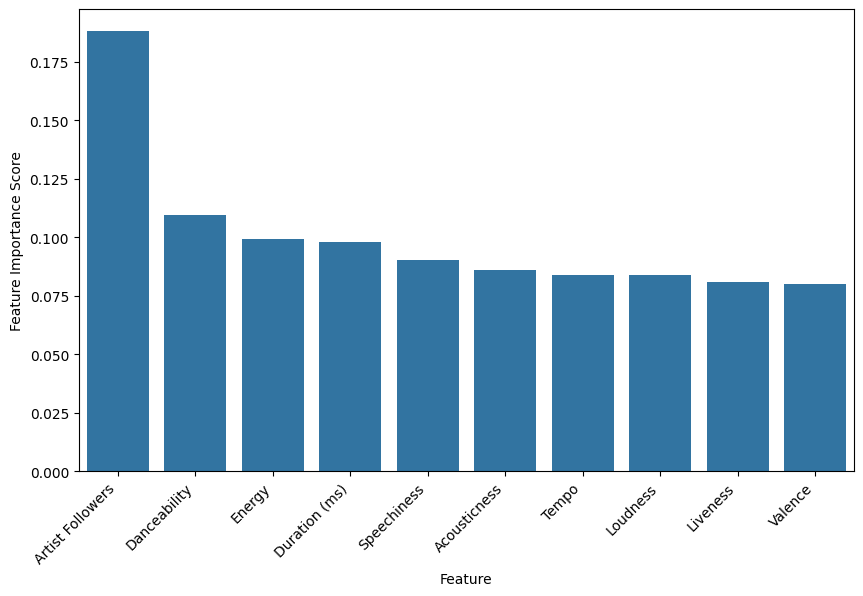

In [ ]:
feat_imp = pd.Series(xgbr.feature_importances_, index=X.columns).sort_values( ascending = False )
plt.figure(figsize = (10,6))
sns.barplot(x = feat_imp.index, y = feat_imp.values )
plt.xticks(rotation=45, ha='right')
plt.xlabel('Feature')
plt.ylabel('Feature Importance Score') ;

In [ ]:
(feat_imp.sort_values( ascending = False )*100).cumsum()

,0
Artist Followers,18.806314
Danceability,29.765612
Energy,39.701096
Duration (ms),49.515480
Speechiness,58.536060
Acousticness,67.129646
Tempo,75.519196
Loudness,83.894897
Liveness,91.999405
Valence,99.999992


### XGBoost for Number of Times Charted


In [ ]:
spotify_NTC = spotify.copy()

In [ ]:
spotify_NTC = spotify_NTC.drop(columns=['Highest Charting Position', 'Streams', 'Popularity'])

In [ ]:
spotify_NTC.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1545 entries, 1 to 1556
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Number of Times Charted  1545 non-null   int64  
 1   Artist Followers         1545 non-null   float64
 2   Danceability             1545 non-null   float64
 3   Energy                   1545 non-null   float64
 4   Loudness                 1545 non-null   float64
 5   Speechiness              1545 non-null   float64
 6   Acousticness             1545 non-null   float64
 7   Liveness                 1545 non-null   float64
 8   Tempo                    1545 non-null   float64
 9   Duration (ms)            1545 non-null   float64
 10  Valence                  1545 non-null   float64
dtypes: float64(10), int64(1)
memory usage: 144.8 KB


In [ ]:
X2 = spotify_NTC.drop('Number of Times Charted', axis = 1)
y2 = spotify_NTC['Number of Times Charted']

In [ ]:
# Specify the parameters you want to try and their ranges.
param_test2 = {
 'max_depth'     : [ 3, 4, 5, 6, 7 ],
 'learning_rate' : [ 0.075, 0.1, 0.2, 0.3, 0.4 ],
 'n_estimators'  : [ 10, 20, 40, 60, 80, 100, 120, 140 ],
}

# Perform the grid search
gsearch = GridSearchCV(
    estimator = xgb.XGBRegressor( objective = 'reg:squarederror', seed = 10 ),
    param_grid = param_test2,
    scoring = 'neg_mean_squared_error',
    cv = 5,
)

# Fit to training data
X2_train, X2_test, y2_train, y2_test = train_test_split(X2,y2,test_size=0.05, random_state = 42 )
model2 = gsearch.fit(X2_train,y2_train)

# See grid search results
print(model2.best_params_)

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 40}


In [ ]:
params = model2.best_params_

numLoops = 500
mse_xgb  = np.zeros(numLoops)

for idx in range(0,numLoops):
  X2_train, X2_test, y2_train, y2_test = train_test_split( X2, y2, test_size = 0.2 )
  xgbr = xgb.XGBRegressor(
      objective ='reg:squarederror',
      verbosity=0,
      **params,
      # learning_rate = 0.1,
      # max_depth = 3,
      # n_estimators = 40,
      seed = 10,
  )
  xgbr.fit(X2_train,y2_train)
  y2_pred_xgb = xgbr.predict(X2_test)
  mse_xgb[idx] = mean_squared_error(y2_test,y2_pred_xgb)

print(f'RMSE: {np.sqrt(mse_xgb).mean()}')

RMSE: 16.192849186374875


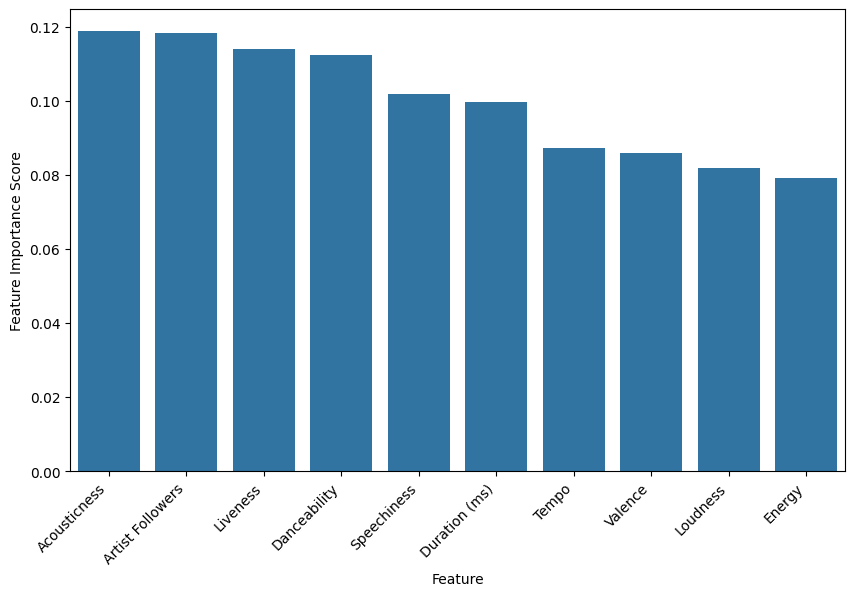

In [ ]:
feat_imp = pd.Series(xgbr.feature_importances_, index=X.columns).sort_values( ascending = False )
plt.figure(figsize = (10,6))
sns.barplot(x = feat_imp.index, y = feat_imp.values )
plt.xticks(rotation=45, ha='right')
plt.xlabel('Feature')
plt.ylabel('Feature Importance Score') ;

In [ ]:
(feat_imp.sort_values( ascending = False )*100).cumsum()

,0
Acousticness,11.879551
Artist Followers,23.707340
Liveness,35.110855
Danceability,46.347378
Speechiness,56.549725
Duration (ms),66.530945
Tempo,75.270004
Valence,83.875488
Loudness,92.076797
Energy,100.000008


### XGBoost for Streams

In [ ]:
spotify_S = spotify.copy()

In [ ]:
spotify_S = spotify_S.drop(columns=['Highest Charting Position', 'Number of Times Charted', 'Popularity'])

In [ ]:
spotify_S.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1545 entries, 1 to 1556
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Streams           1545 non-null   int64  
 1   Artist Followers  1545 non-null   float64
 2   Danceability      1545 non-null   float64
 3   Energy            1545 non-null   float64
 4   Loudness          1545 non-null   float64
 5   Speechiness       1545 non-null   float64
 6   Acousticness      1545 non-null   float64
 7   Liveness          1545 non-null   float64
 8   Tempo             1545 non-null   float64
 9   Duration (ms)     1545 non-null   float64
 10  Valence           1545 non-null   float64
dtypes: float64(10), int64(1)
memory usage: 144.8 KB


In [ ]:
X3 = spotify_S.drop('Streams', axis = 1)
y3 = spotify_S['Streams']

In [ ]:
# Specify the parameters you want to try and their ranges.
param_test3 = {
 'max_depth'     : [ 3, 4, 5, 6, 7 ],
 'learning_rate' : [ 0.075, 0.1, 0.2, 0.3, 0.4 ],
 'n_estimators'  : [ 5, 10, 20, 40, 60, 80, 100, 120, 140 ],
}

# Perform the grid search
gsearch = GridSearchCV(
    estimator = xgb.XGBRegressor( objective = 'reg:squarederror', seed = 10 ),
    param_grid = param_test3,
    scoring = 'neg_mean_squared_error',
    cv = 10,
)

# Fit to training data
X3_train, X3_test, y3_train, y3_test = train_test_split(X3,y3,test_size=0.05, random_state = 42 )
model3 = gsearch.fit(X3_train,y3_train)

# See grid search results
print(model3.best_params_)

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 20}


In [ ]:
params = model3.best_params_

numLoops = 500
mse_xgb  = np.zeros(numLoops)

for idx in range(0,numLoops):
  X3_train, X3_test, y3_train, y3_test = train_test_split( X3, y3, test_size = 0.2 )
  xgbr = xgb.XGBRegressor(
      objective ='reg:squarederror',
      verbosity=0,
      **params,
      # learning_rate = 0.1,
      # max_depth = 3,
      # n_estimators = 20,
      seed = 10,
  )
  xgbr.fit(X3_train,y3_train)
  y3_pred_xgb = xgbr.predict(X3_test)
  mse_xgb[idx] = mean_squared_error(y3_test,y3_pred_xgb)

print(f'RMSE: {np.sqrt(mse_xgb).mean()}')

RMSE: 3350829.4899318563


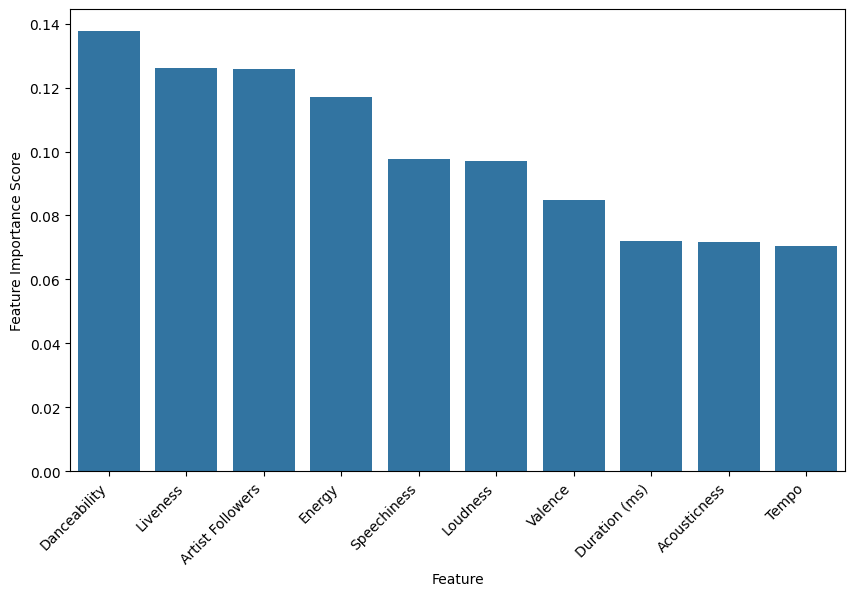

In [ ]:
feat_imp = pd.Series(xgbr.feature_importances_, index=X.columns).sort_values( ascending = False )
plt.figure(figsize = (10,6))
sns.barplot(x = feat_imp.index, y = feat_imp.values )
plt.xticks(rotation=45, ha='right')
plt.xlabel('Feature')
plt.ylabel('Feature Importance Score') ;

In [ ]:
(feat_imp.sort_values( ascending = False )*100).cumsum()

,0
Danceability,13.753345
Liveness,26.364326
Artist Followers,38.941727
Energy,50.649860
Speechiness,60.422382
Loudness,70.116348
Valence,78.595963
Duration (ms),85.800095
Acousticness,92.965523
Tempo,99.999992


### XGBoost for Popularity

In [ ]:
spotify_P = spotify.copy()

In [ ]:
spotify_P = spotify_P.drop(columns=['Highest Charting Position', 'Number of Times Charted', 'Streams'])

In [ ]:
spotify_P.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1545 entries, 1 to 1556
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Artist Followers  1545 non-null   float64
 1   Popularity        1545 non-null   float64
 2   Danceability      1545 non-null   float64
 3   Energy            1545 non-null   float64
 4   Loudness          1545 non-null   float64
 5   Speechiness       1545 non-null   float64
 6   Acousticness      1545 non-null   float64
 7   Liveness          1545 non-null   float64
 8   Tempo             1545 non-null   float64
 9   Duration (ms)     1545 non-null   float64
 10  Valence           1545 non-null   float64
dtypes: float64(11)
memory usage: 144.8 KB


In [ ]:
X4 = spotify_P.drop('Popularity', axis = 1)
y4 = spotify_P['Popularity']

In [ ]:
# Specify the parameters you want to try and their ranges.
param_test4 = {
 'max_depth'     : [ 3, 4, 5, 6, 7 ],
 'learning_rate' : [ 0.075, 0.1, 0.2, 0.3, 0.4 ],
 'n_estimators'  : [ 10, 20, 40, 60, 80, 100, 120, 140 ],
}

# Perform the grid search
gsearch = GridSearchCV(
    estimator = xgb.XGBRegressor( objective = 'reg:squarederror', seed = 10 ),
    param_grid = param_test4,
    scoring = 'neg_mean_squared_error',
    cv = 10,
)

# Fit to training data
X4_train, X4_test, y4_train, y4_test = train_test_split(X4, y4, test_size=0.05, random_state = 42 )
model4 = gsearch.fit(X4_train,y4_train)

# See grid search results
print(model4.best_params_)

{'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 140}


In [ ]:
params = model4.best_params_

numLoops = 500
mse_xgb  = np.zeros(numLoops)

for idx in range(0,numLoops):
  X4_train, X4_test, y4_train, y4_test = train_test_split( X4, y4, test_size = 0.2 )
  xgbr = xgb.XGBRegressor(
      objective ='reg:squarederror',
      verbosity=0,
      **params,
      # learning_rate = 0.1,
      # max_depth = 4,
      # n_estimators = 140,
      seed = 10,
  )
  xgbr.fit(X4_train,y4_train)
  y4_pred_xgb = xgbr.predict(X4_test)
  mse_xgb[idx] = mean_squared_error(y4_test,y4_pred_xgb)

print(f'RMSE: {np.sqrt(mse_xgb).mean()}')

RMSE: 11.083865667585611


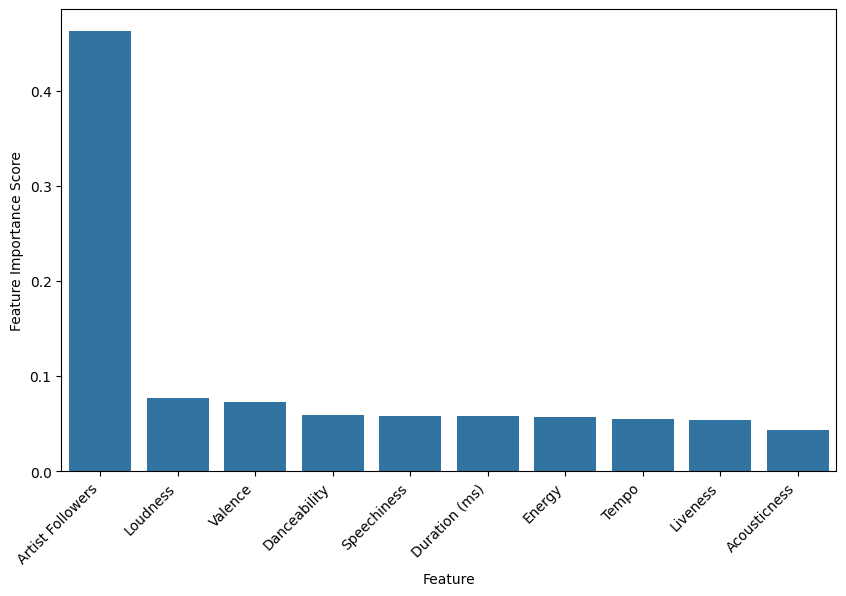

In [ ]:
feat_imp = pd.Series(xgbr.feature_importances_, index=X.columns).sort_values( ascending = False )
plt.figure(figsize = (10,6))
sns.barplot(x = feat_imp.index, y = feat_imp.values )
plt.xticks(rotation=45, ha='right')
plt.xlabel('Feature')
plt.ylabel('Feature Importance Score') ;

In [ ]:
(feat_imp.sort_values( ascending = False )*100).cumsum()

,0
Artist Followers,46.273033
Loudness,53.962116
Valence,61.294949
Danceability,67.249397
Speechiness,73.076874
Duration (ms),78.898766
Energy,84.595108
Tempo,90.138748
Liveness,95.595428
Acousticness,100.000015


## General Statistics

In [ ]:
spotify.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Highest Charting Position,1545.0,8.782524e+01,5.813205e+01,1.000000e+00,3.700000e+01,8.000000e+01,1.370000e+02,2.000000e+02
Number of Times Charted,1545.0,1.068414e+01,1.638976e+01,1.000000e+00,1.000000e+00,4.000000e+00,1.200000e+01,1.420000e+02
Streams,1545.0,6.337136e+06,3.375402e+06,4.176083e+06,4.915080e+06,5.269163e+06,6.452492e+06,4.863345e+07
Artist Followers,1545.0,1.471690e+07,1.667579e+07,4.883000e+03,2.123734e+06,6.852509e+06,2.269875e+07,8.333778e+07
Popularity,1545.0,7.008932e+01,1.582403e+01,0.000000e+00,6.500000e+01,7.300000e+01,8.000000e+01,1.000000e+02
Danceability,1545.0,6.899968e-01,1.424440e-01,1.500000e-01,5.990000e-01,7.070000e-01,7.960000e-01,9.800000e-01
Energy,1545.0,6.334951e-01,1.615770e-01,5.400000e-02,5.320000e-01,6.420000e-01,7.520000e-01,9.700000e-01
Loudness,1545.0,-6.348474e+00,2.509281e+00,-2.516600e+01,-7.491000e+00,-5.990000e+00,-4.711000e+00,1.509000e+00
Speechiness,1545.0,1.236557e-01,1.103827e-01,2.320000e-02,4.560000e-02,7.650000e-02,1.650000e-01,8.840000e-01
Acousticness,1545.0,2.486945e-01,2.503259e-01,2.550000e-05,4.850000e-02,1.610000e-01,3.880000e-01,9.940000e-01


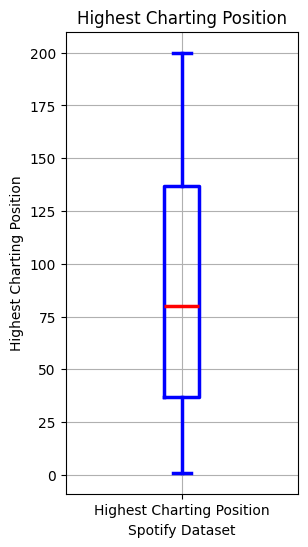

In [ ]:
columns_to_plot = ['Highest Charting Position']

props = {
    'linewidth': 2.5,
    'color': 'blue'
}

ax = spotify.boxplot(
    column=columns_to_plot,
    boxprops=props,
    whiskerprops=props,
    capprops=props,
    medianprops={'linewidth': 2.5, 'color': 'red'},
    figsize=(3, 6)
)

ax.set_xlabel('Spotify Dataset')
ax.set_ylabel('Highest Charting Position')
ax.set_title('Highest Charting Position')

plt.show()

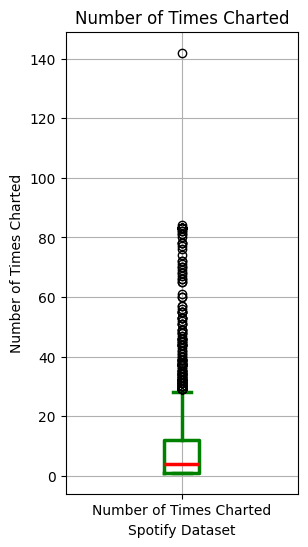

In [ ]:
columns_to_plot = ['Number of Times Charted']

props = {
    'linewidth': 2.5,
    'color': 'green'
}

ax = spotify.boxplot(
    column=columns_to_plot,
    boxprops=props,
    whiskerprops=props,
    capprops=props,
    medianprops={'linewidth': 2.5, 'color': 'red'},
    figsize=(3, 6)
)

ax.set_xlabel('Spotify Dataset')
ax.set_ylabel('Number of Times Charted')
ax.set_title('Number of Times Charted')

plt.show()

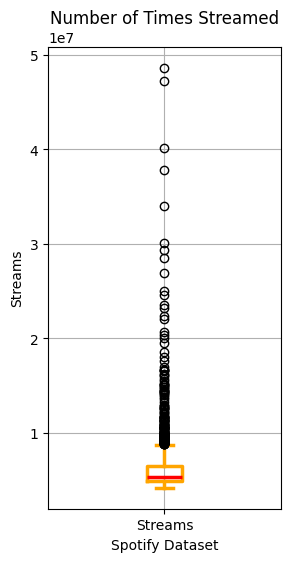

In [ ]:
columns_to_plot = ['Streams']

props = {
    'linewidth': 2.5,
    'color': 'orange'
}

ax = spotify.boxplot(
    column=columns_to_plot,
    boxprops=props,
    whiskerprops=props,
    capprops=props,
    medianprops={'linewidth': 2.5, 'color': 'red'},
    figsize=(3, 6)
)

ax.set_xlabel('Spotify Dataset')
ax.set_ylabel('Streams')
ax.set_title('Number of Times Streamed')

plt.show()

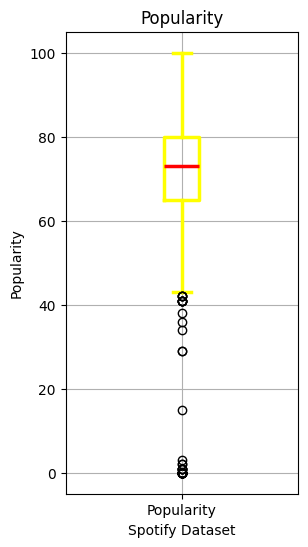

In [ ]:
columns_to_plot = ['Popularity']

props = {
    'linewidth': 2.5,
    'color': 'yellow'
}

ax = spotify.boxplot(
    column=columns_to_plot,
    boxprops=props,
    whiskerprops=props,
    capprops=props,
    medianprops={'linewidth': 2.5, 'color': 'red'},
    figsize=(3, 6)
)

ax.set_xlabel('Spotify Dataset')
ax.set_ylabel('Popularity')
ax.set_title('Popularity')

plt.show()

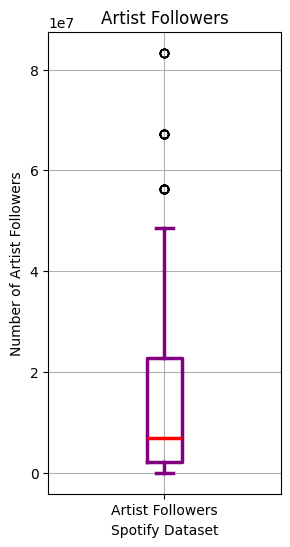

In [ ]:
columns_to_plot = ['Artist Followers']

props = {
    'linewidth': 2.5,
    'color': 'purple'
}

ax = spotify.boxplot(
    column=columns_to_plot,
    boxprops=props,
    whiskerprops=props,
    capprops=props,
    medianprops={'linewidth': 2.5, 'color': 'red'},
    figsize=(3, 6)
)

ax.set_xlabel('Spotify Dataset')
ax.set_ylabel('Number of Artist Followers')
ax.set_title('Artist Followers')

plt.show()

The data for Highest Charting Position, Number of Times Charted and Streams are right skewed and have a large tail. Reading online mentioned that while XGBoost does very well with skewed features, skewed target data can cause the large target data to dominate the tree splits.  So this data will be log transformed.

## Transforming the data before prediction

In reading more about how to do the transformation and what transformation to pick for XGBoost, I noted "TransformedTargetRegressor" is being used as a method to faciliate transforming the target in the prediction. So I will use this.

In [ ]:
from sklearn.compose import TransformedTargetRegressor

I used Gemini to help modify the code I had been using.  The explainations that resulted from the discussion with Gemini are kept here for additional understanding

### Transformed XGBoost for Highest Charting Position

In [ ]:
# 1. Setup the Parameters with the 'regressor__' prefix
# This is required because TTR "wraps" the XGBoost model
param_test1b = {
 'regressor__max_depth'    : [ 3, 4, 5, 6, 7 ],
 'regressor__learning_rate' : [ 0.075, 0.1, 0.2, 0.3, 0.4 ],
 'regressor__n_estimators'  : [ 10, 20, 40, 60, 80, 100, 120, 140 ],
}

# 2. Define the Base Estimator and the Wrapper
xgb_base = xgb.XGBRegressor(objective='reg:squarederror', seed=10)

ttr_wrapper = TransformedTargetRegressor(
    regressor=xgb_base,
    func=np.log,
    inverse_func=np.exp
)

# 3. Perform the grid search
# We use n_jobs=-1 here to make the 2,000 fits go way faster
# I suspect it wont work in colab but I am retaining the code so that I can use it later
gsearch = GridSearchCV(
    estimator = ttr_wrapper,
    param_grid = param_test1b,
    scoring = 'neg_mean_squared_error',
    cv = 10,
    n_jobs = -1
)

# Initial split for grid search
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05, random_state=42)
model1b = gsearch.fit(X_train, y_train)

print(f"Best Params: {model1b.best_params_}")

Best Params: {'regressor__learning_rate': 0.075, 'regressor__max_depth': 4, 'regressor__n_estimators': 80}


In [ ]:
# 4. Preparation for the Loop
# We strip the 'regressor__' prefix so we can pass params back into a clean model
best_params = {k.replace('regressor__', ''): v for k, v in model1b.best_params_.items()}

numLoops = 500
mse_xgb = np.zeros(numLoops)

for idx in range(0, numLoops):
    # New split for every loop
    X_train_loop, X_test_loop, y_train_loop, y_test_loop = train_test_split(X, y, test_size=0.2)

    # Re-create the wrapped model with the best parameters
    xgbr_base = xgb.XGBRegressor(
        objective='reg:squarederror',
        verbosity=0,
        seed=10,
        **best_params
    )

    # We must wrap it here too so the training in the loop uses the log logic!
    xgbr_wrapped = TransformedTargetRegressor(
        regressor=xgbr_base,
        func=np.log,
        inverse_func=np.exp
    )

    xgbr_wrapped.fit(X_train_loop, y_train_loop)

    # TTR's predict automatically converts the log back to the original scale
    y_pred_xgb = xgbr_wrapped.predict(X_test_loop)

    # Calculate MSE on the original (back-transformed) scale
    mse_xgb[idx] = mean_squared_error(y_test_loop, y_pred_xgb)

# 5. Final Result
print(f'Average RMSE over {numLoops} loops: {np.sqrt(mse_xgb).mean()}')

Average RMSE over 500 loops: 61.986462074693044


### Transformed XGBoost for Number of Times Charted

In [ ]:
# 1. Setup the Parameters with the 'regressor__' prefix
# This is required because TTR "wraps" the XGBoost model
param_test2b = {
 'regressor__max_depth'    : [ 3, 4, 5, 6, 7 ],
 'regressor__learning_rate' : [ 0.075, 0.1, 0.2, 0.3, 0.4 ],
 'regressor__n_estimators'  : [ 10, 20, 40, 60, 80, 100, 120, 140 ],
}

# 2. Define the Base Estimator and the Wrapper
xgb_base = xgb.XGBRegressor(objective='reg:squarederror', seed=10)

ttr_wrapper = TransformedTargetRegressor(
    regressor=xgb_base,
    func=np.log,
    inverse_func=np.exp
)

# 3. Perform the grid search
# We use n_jobs=-1 here to make the 2,000 fits go way faster
# I suspect it wont work in colab but I am retaining the code so that I can use it later
gsearch = GridSearchCV(
    estimator = ttr_wrapper,
    param_grid = param_test1b,
    scoring = 'neg_mean_squared_error',
    cv = 10,
    n_jobs = -1
)

# Initial split for grid search
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.05, random_state=42)
model2b = gsearch.fit(X2_train, y2_train)

print(f"Best Params: {model2b.best_params_}")

Best Params: {'regressor__learning_rate': 0.4, 'regressor__max_depth': 3, 'regressor__n_estimators': 60}


In [ ]:
# 4. Preparation for the Loop
# We strip the 'regressor__' prefix so we can pass params back into a clean model
best_params = {k.replace('regressor__', ''): v for k, v in model2b.best_params_.items()}

numLoops = 500
mse_xgb = np.zeros(numLoops)

for idx in range(0, numLoops):
    # New split for every loop
    X2_train_loop, X2_test_loop, y2_train_loop, y2_test_loop = train_test_split(X2, y2, test_size=0.2)

    # Re-create the wrapped model with the best parameters
    xgbr_base = xgb.XGBRegressor(
        objective='reg:squarederror',
        verbosity=0,
        seed=10,
        **best_params
    )

    # We must wrap it here too so the training in the loop uses the log logic!
    xgbr_wrapped = TransformedTargetRegressor(
        regressor=xgbr_base,
        func=np.log,
        inverse_func=np.exp
    )

    xgbr_wrapped.fit(X2_train_loop, y2_train_loop)

    # TTR's predict automatically converts the log back to the original scale
    y2_pred_xgb = xgbr_wrapped.predict(X2_test_loop)

    # Calculate MSE on the original (back-transformed) scale
    mse_xgb[idx] = mean_squared_error(y2_test_loop, y2_pred_xgb)

# 5. Final Result
print(f'Average RMSE over {numLoops} loops: {np.sqrt(mse_xgb).mean()}')

Average RMSE over 500 loops: 16.9979768773032


### Transformed XGBoost for Steams

In [ ]:
# 1. Setup the Parameters with the 'regressor__' prefix
# This is required because TTR "wraps" the XGBoost model
param_test3b = {
 'regressor__max_depth'    : [ 3, 4, 5, 6, 7 ],
 'regressor__learning_rate' : [ 0.075, 0.1, 0.2, 0.3, 0.4 ],
 'regressor__n_estimators'  : [ 10, 20, 40, 60, 80, 100, 120, 140 ],
}

# 2. Define the Base Estimator and the Wrapper
xgb_base = xgb.XGBRegressor(objective='reg:squarederror', seed=10)

ttr_wrapper = TransformedTargetRegressor(
    regressor=xgb_base,
    func=np.log,
    inverse_func=np.exp
)

# 3. Perform the grid search
# We use n_jobs=-1 here to make the 2,000 fits go way faster
# I suspect it wont work in colab but I am retaining the code so that I can use it later
gsearch = GridSearchCV(
    estimator = ttr_wrapper,
    param_grid = param_test1b,
    scoring = 'neg_mean_squared_error',
    cv = 10,
    n_jobs = -1
)

# Initial split for grid search
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.05, random_state=42)
model3b = gsearch.fit(X3_train, y3_train)

print(f"Best Params: {model3b.best_params_}")

Best Params: {'regressor__learning_rate': 0.075, 'regressor__max_depth': 4, 'regressor__n_estimators': 60}


In [ ]:
# 4. Preparation for the Loop
# We strip the 'regressor__' prefix so we can pass params back into a clean model
best_params = {k.replace('regressor__', ''): v for k, v in model3b.best_params_.items()}

numLoops = 500
mse_xgb = np.zeros(numLoops)

for idx in range(0, numLoops):
    # New split for every loop
    X3_train_loop, X3_test_loop, y3_train_loop, y3_test_loop = train_test_split(X3, y3, test_size=0.2)

    # Re-create the wrapped model with the best parameters
    xgbr_base = xgb.XGBRegressor(
        objective='reg:squarederror',
        verbosity=0,
        seed=10,
        **best_params
    )

    # We must wrap it here too so the training in the loop uses the log logic!
    xgbr_wrapped = TransformedTargetRegressor(
        regressor=xgbr_base,
        func=np.log,
        inverse_func=np.exp
    )

    xgbr_wrapped.fit(X3_train_loop, y3_train_loop)

    # TTR's predict automatically converts the log back to the original scale
    y3_pred_xgb = xgbr_wrapped.predict(X3_test_loop)

    # Calculate MSE on the original (back-transformed) scale
    mse_xgb[idx] = mean_squared_error(y3_test_loop, y3_pred_xgb)

# 5. Final Result
print(f'Average RMSE over {numLoops} loops: {np.sqrt(mse_xgb).mean()}')

Average RMSE over 500 loops: 3299600.154681135


The use of log transformation did not help the prediction on Highest Charting Postition or Number of Times Charted.  There was a small help with Streams, but the effect was not very strong and likely within the noise.  


## Testing Tweedie Loss to handle the skewed data

Further reading suggests modifying the objective function from the standard (reg:squarederror) to Tweedie Loss (reg:tweedie). This is suposed to be highly effective for heavily skewed, zero-inflated, or continuous data with a long tail.

### Tweedie loss for Highest Charting Position

In [ ]:
# Specify the parameters you want to try and their ranges.
param_test1c = {
 'max_depth'     : [ 3, 4, 5, 6, 7 ],
 'learning_rate' : [ 0.075, 0.1, 0.2, 0.3, 0.4 ],
 'n_estimators'  : [ 5, 10, 20, 40, 60, 80, 100, 120, 140 ],
}

# Perform the grid search
gsearch = GridSearchCV(
    estimator = xgb.XGBRegressor( objective = 'reg:tweedie', seed = 10 ),
    param_grid = param_test1c,
    scoring = 'neg_mean_squared_error',
    cv = 10,
)

# Fit to training data
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.05, random_state = 42 )
model1c = gsearch.fit(X_train,y_train)

# See grid search results
print(model1c.best_params_)

In [ ]:
params = model1c.best_params_

numLoops = 500
mse_xgb  = np.zeros(numLoops)

for idx in range(0,numLoops):
  X_train, X_test, y_train, y_test = train_test_split( X, y, test_size = 0.2 )
  xgbr = xgb.XGBRegressor(
      objective ='reg:tweedie',
      verbosity=0,
      **params,
      # learning_rate = 0.1,
      # max_depth = 4,
      # n_estimators = 140,
      seed = 10,
  )
  xgbr.fit(X_train,y_train)
  y_pred_xgb = xgbr.predict(X_test)
  mse_xgb[idx] = mean_squared_error(y_test,y_pred_xgb)

print(f'RMSE: {np.sqrt(mse_xgb).mean()}')

### Tweedie loss for Number of Times Charted

In [ ]:
# Specify the parameters you want to try and their ranges.
param_test2c = {
 'max_depth'     : [ 3, 4, 5, 6, 7 ],
 'learning_rate' : [ 0.075, 0.1, 0.2, 0.3, 0.4 ],
 'n_estimators'  : [ 5, 10, 20, 40, 60, 80, 100, 120, 140 ],
}

# Perform the grid search
gsearch = GridSearchCV(
    estimator = xgb.XGBRegressor( objective = 'reg:tweedie', seed = 10 ),
    param_grid = param_test1c,
    scoring = 'neg_mean_squared_error',
    cv = 10,
)

# Fit to training data
X2_train, X2_test, y2_train, y2_test = train_test_split(X2,y2,test_size=0.05, random_state = 42 )
model2c = gsearch.fit(X2_train,y2_train)

# See grid search results
print(model2c.best_params_)

In [ ]:
params = model2c.best_params_

numLoops = 500
mse_xgb  = np.zeros(numLoops)

for idx in range(0,numLoops):
  X2_train, X2_test, y2_train, y2_test = train_test_split( X2, y2, test_size = 0.2 )
  xgbr = xgb.XGBRegressor(
      objective ='reg:tweedie',
      verbosity=0,
      **params,
      # learning_rate = 0.1,
      # max_depth = 4,
      # n_estimators = 140,
      seed = 10,
  )
  xgbr.fit(X2_train,y2_train)
  y2_pred_xgb = xgbr.predict(X2_test)
  mse_xgb[idx] = mean_squared_error(y2_test,y2_pred_xgb)

print(f'RMSE: {np.sqrt(mse_xgb).mean()}')

### Twedie loss for Streams

In [ ]:
 #Specify the parameters you want to try and their ranges.
param_test3c = {
 'max_depth'     : [ 3, 4, 5, 6, 7 ],
 'learning_rate' : [ 0.075, 0.1, 0.2, 0.3, 0.4 ],
 'n_estimators'  : [ 5, 10, 20, 40, 60, 80, 100, 120, 140 ],
}

# Perform the grid search
gsearch = GridSearchCV(
    estimator = xgb.XGBRegressor( objective = 'reg:tweedie', seed = 10 ),
    param_grid = param_test1c,
    scoring = 'neg_mean_squared_error',
    cv = 10,
)

# Fit to training data
X3_train, X3_test, y3_train, y3_test = train_test_split(X3,y3,test_size=0.05, random_state = 42 )
model3c = gsearch.fit(X3_train,y3_train)

# See grid search results
print(model3c.best_params_)

In [ ]:
params = model3c.best_params_

numLoops = 500
mse_xgb  = np.zeros(numLoops)

for idx in range(0,numLoops):
  X3_train, X3_test, y3_train, y3_test = train_test_split( X3, y3, test_size = 0.2 )
  xgbr = xgb.XGBRegressor(
      objective ='reg:tweedie',
      verbosity=0,
      **params,
      # learning_rate = 0.1,
      # max_depth = 4,
      # n_estimators = 140,
      seed = 10,
  )
  xgbr.fit(X3_train,y3_train)
  y3_pred_xgb = xgbr.predict(X3_test)
  mse_xgb[idx] = mean_squared_error(y3_test,y3_pred_xgb)

print(f'RMSE: {np.sqrt(mse_xgb).mean()}')

### Tweedie loss for Popularity

In [ ]:
_ #Specify the parameters you want to try and their ranges.
param_test4c = {
 'max_depth'     : [ 3, 4, 5, 6, 7 ],
 'learning_rate' : [ 0.075, 0.1, 0.2, 0.3, 0.4 ],
 'n_estimators'  : [ 5, 10, 20, 40, 60, 80, 100, 120, 140 ],
}

# Perform the grid search
gsearch = GridSearchCV(
    estimator = xgb.XGBRegressor( objective = 'reg:tweedie', seed = 10 ),
    param_grid = param_test1c,
    scoring = 'neg_mean_squared_error',
    cv = 10,
)

# Fit to training data
X4_train, X4_test, y4_train, y4_test = train_test_split(X4,y4,test_size=0.05, random_state = 42 )
model4c = gsearch.fit(X4_train,y4_train)

# See grid search results
print(model4c.best_params_)

In [ ]:
params = model4c.best_params_

numLoops = 500
mse_xgb  = np.zeros(numLoops)

for idx in range(0,numLoops):
  X4_train, X4_test, y4_train, y4_test = train_test_split( X4, y4, test_size = 0.2 )
  xgbr = xgb.XGBRegressor(
      objective ='reg:squarederror',
      verbosity=0,
      **params,
      # learning_rate = 0.1,
      # max_depth = 4,
      # n_estimators = 140,
      seed = 10,
  )
  xgbr.fit(X4_train,y4_train)
  y4_pred_xgb = xgbr.predict(X4_test)
  mse_xgb[idx] = mean_squared_error(y4_test,y4_pred_xgb)

print(f'RMSE: {np.sqrt(mse_xgb).mean()}')

## Conclusions and Future Plans



### Conclusions

Descriptive Statistics

| Response variable | Highest Charting Position | Number of times Charted | Streams | Popularity |
| :--- | :---: | :---: | :---: | :---: |
| **Mean** | 87.83 | 10.68 | 6,337,136 | 70.09 |
| **St Dev** | 58.13 | 16.39 | 3,375,402 | 15.82 |
| **XGBoost RMSE** | 55.95 | 16.17 | 3,302,231 | 11.08 |
| **Transformed XGBoost RMSE** | 62.22 | 16.92 | 3,274,399 | |
| **Tweedie loss XGBoost RMSE** | 55.91 | 16.21 | 3,349,337 | 11.11 |

If you look across the various XGBoost variations, the use of additional methods, such as Tweedie Loss or Transformation did not improve the RMSE.  Suggesting, at least for this data set, these methods did not improve the prediction.  

However, to compare across the various popularity methods the RMSE must be normalized.  There are several ways to normalize RMSE, in this case normalization to the mean was used

NRMSE= RMSE/mean y

Normalized RMSE

| Response variable | Highest Charting Position | Number of times Charted | Streams | Popularity |
| :--- | :---: | :---: | :---: | :---: |
| **XGBoost NRMSE** | 0.63702607 | 1.51404 | 0.52109 | 0.1580825 |
| **Transformed XGBoost NRMSE** | 0.70841398 | 1.58427 | 0.51670 | |
| **Tweedie loss XGBoost NRMSE** | 0.63657065 | 1.51779 | 0.52853 | 0.1585105 |

When examined this wat, popularity stands out as the clear winner for RMSE prediction.  However, this is likely due to the use of the Spotify defined Popularity target, as this data is likely used to define this target.  If the Spotify defined popularity is not used, the next best predictor for an unreleased song would be to predict the likely number of streams from the numerical characteristics.  

### Future work

The current predictions focus entirely on one model type (XGBoost) and numerical data only.  

Addition of a scrubbed version of the Genre data and looking at the effeccts of release year might increase the predictiveness and potentially provide additional insight into the data.

In this first round, the focus was on XGBoost due to personal interest, but this methodology was not compared to other prediction models, so exploring additional models like Decision Trees and Random Forrest my create a better model.